<a href="https://colab.research.google.com/github/MariaHinestroza04/Analitica-Negocios/blob/main/Parcial_1_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de Estudio:**
Una entidad de Salud, requiere un modelo para la clasificación de pacientes que poseen diabetes. Según esto, las variables que seran utilizadas seran las siguientes:

* Glucosa: nivel de concentración de glucosa en sangre, fundamental para el analisis de diabetes.

* BMI: índice de masa corporal, que relaciona peso y altura con composición corporal.

* Edad: edad del paciente en años.

* Embarazos: número de embarazos que ha tenido la paciente. Relacionado a la diabetes gestacional


A partir de estas variables, se aplicarán tres técnicas de analítica de negocios: Naive Bayes, Árboles de Decisión y Clustering K-Means, con el fin de evaluar su capacidad para clasificar correctamente a los pacientes según la presencia de diabetes.

0. Importar todas las librerias pertinentes para poder desarrollar los 3 modelos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.cluster import KMeans

1. Cargar los datos de trabajo

In [ ]:
nxl='/content/diabetes.csv'
XDB=pd.read_csv(nxl)
XD=XDB.iloc[:,[0,1,4,6]]
yd=XDB.iloc[:,[7]]

2. Analisis de Correlación

<Axes: >

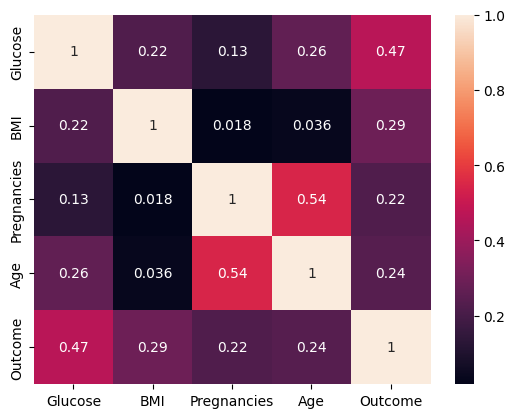

In [ ]:
columns_for_correlation = ['Glucose', 'BMI', 'Pregnancies', 'Age', 'Outcome']
XDB2 = XDB[columns_for_correlation]
sns.heatmap(XDB2.corr(), annot=True)

***Analisis de resultados 1:***

En el heat map se puede observar que las variables que tienen una mayor correlación entre ellas son las variables embarazo y edad con un 54%.

Se destaca igualmetne la variable que tiene la mayor corelacion con la variable de salida (outcome), la de glucosa.

3. Modelo Naive Bayes

In [ ]:
XD=XDB[["Glucose","BMI","Age","Pregnancies"]]
XD.head(10)
yd=XDB[["Outcome"]] #Esta la variable de decision
yd.head()

mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar Variables de entrada-salida

#Mostrar las medias de las variables
u=mnb.theta_
sigma=mnb.var_; sigma= np.sqrt(sigma)
print("Glucose","BMI","Age","Pregnancies")
print(u)
print("Las desviaciones son: ")
print(sigma)

ydp=mnb.predict(XD) #Esto el lo que el modelo aprende - ydp de pronostico
cm=confusion_matrix(yd,ydp)
print(cm)

#Matriz de confusion para la evaluacion del modelo:
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)
Ex=((VP+VN)/TDatos)*100
print("Exactitud: ", Ex)
TE=(1-Ex)
print("Tasa de error: ", TE)
Se=(VP/(VP+FN))*100
print("Sensibilidad: ", Se)
Es=(VN/(VN+FP))*100
print("Especifisidad: ", Es)
Pr=(VP/(VP+FP))*100
print("Precision: ", Pr)
PrN=(VN/(VN+FN))*100
print("Prediccion negativa: ", PrN)

Glucose BMI Age Pregnancies
[[109.98        30.3042      31.19         3.298     ]
 [141.25746269  35.14253731  37.06716418   4.86567164]]
Las desviaciones son: 
[[26.11504549  7.68216137 11.65598134  3.01416606]
 [31.87997754  7.24940434 10.94777141  3.73425273]]
[[426  74]
 [110 158]]
Exactitud:  76.04166666666666
Tasa de error:  -75.04166666666666
Sensibilidad:  58.95522388059702
Especifisidad:  85.2
Precision:  68.10344827586206
Prediccion negativa:  79.47761194029852


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Analisis de resultados Naive Bayes:**

El modelo identifico diferencias importantes entre los pacientes con diabetes y sin diabetes a partir de los valores promedio.

* Se observa que los pacientes diagnosticados con diabetes presentan mayores valores promedio de glucosa, BMI, edad y número de embarazos, lo que muestra que si son variables que afectan a las persoans con diabetes principalmente.

* La variable glucosa muestra la mayor diferencia lo cual demuestra el comportamiento clínico de la enfermedad.

* Las desviaciones estándar indican que existe variabilidad en los valores dentro de cada grupo, pero los limites permiten identificar patrones que ayudan al modelo a diferenciar entre pacientes diabéticos y no diabéticos.

4. Árboles de decisión

In [ ]:
XD=XDB.iloc[:,[0,1,5,7]]
yd=XDB.iloc[:,8]
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)
ydp=mar.predict(XD)
#Despliegue del arbol
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
vs=["Glucose", "BMI", "Age", "Pregnancies"]
dot_data=export_graphviz(mar,feature_names=vs)
graph=graph_from_dot_data(dot_data)
graph.write_png("arbol.png")

#Matriz de confusion para la evaluacion del modelo:
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)
Ex=((VP+VN)/TDatos)*100
print("Exactitud: ", Ex)
TE=(1-Ex)
print("Tasa de error: ", TE)
Se=(VP/(VP+FN))*100
print("Sensibilidad: ", Se)
Es=(VN/(VN+FP))*100
print("Especifisidad: ", Es)
Pr=(VP/(VP+FP))*100
print("Precision: ", Pr)
PrN=(VN/(VN+FN))*100
print("Prediccion negativa: ", PrN)

Exactitud:  76.04166666666666
Tasa de error:  -75.04166666666666
Sensibilidad:  58.95522388059702
Especifisidad:  85.2
Precision:  68.10344827586206
Prediccion negativa:  79.47761194029852


**Analisis de resultados arbol de decisión:**

El árbol de decisión construido con cuatro niveles permite identificar las variables más relevantes para la clasificación de pacientes con y sin diabetes.
* La variable que aparece en la raíz del árbol es BMI, lo que indica que el índice de masa corporal es uno de los factores más influyentes en la separación inicial de los datos.
* En el árbol se identifican 7 nodos puros, el que tiene mayor número de datos contiene 39 observaciones, con un valor 39, 0 indicando que todos los pacientes en ese nodo pertenecen a no diabéticos.

* Las condiciones del árbol, por ejemplo valores bajos en variables como edad y BMI son clasificadas completamente dentro de la clase no diabética en el modelo.

5. Clusterización K-means

,Pregnancies,Glucose,BMI,Age
0,3.698113,121.740566,32.527358,32.367925
1,4.273684,178.905263,35.890526,37.842105
2,3.289796,99.310204,29.988571,29.771429
3,3.506329,72.075949,29.839241,29.708861
4,4.963504,146.109489,33.287591,39.642336


El numero de datos por cluster es: [211  95 246  79 137]


/tmp/ipykernel_299/2964165556.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['cluster']=ydp


,Glucose,BMI,Pregnancies,Age,Outcome,cluster
0,148,33.6,6,50,1,4
1,85,26.6,1,31,0,3
2,183,23.3,8,32,1,1
3,89,28.1,1,21,0,2
4,137,43.1,0,33,1,4
...,...,...,...,...,...,...
763,101,32.9,10,63,0,2
764,122,36.8,2,27,0,0
765,121,26.2,5,30,0,0
766,126,30.1,1,47,1,0


,Diabetes,No Diabetes
0,75,136
1,79,16
2,37,209
3,6,73
4,71,66


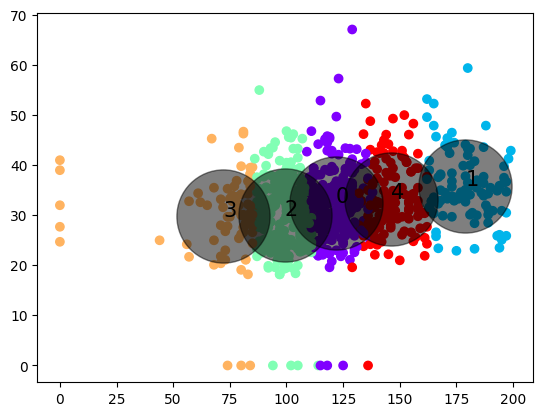

In [ ]:
np.random.seed()
NC=5
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd)
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)
ydp=mkm.labels_ #Me indica enq eu cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Numero de datos por segmento
print("El numero de datos por cluster es:",NDc)

#Porcentaje de tener diabetes
XDB2['cluster']=ydp
display(XDB2)

Napr=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==1).sum()})
Nprn=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==0).sum()})

Napr2=Napr/(Napr+Nprn); Nprn2=Nprn/(Napr+Nprn)
df2=pd.DataFrame(np.column_stack((Napr,Nprn)),columns=['Diabetes','No Diabetes'])
display(df2)

#Grafica de clusters
centers=mkm.cluster_centers_ #Centroides, perfil o segmento
ing=np.array(XD.iloc[:,1])
egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')
plt.scatter(centers[:,1],centers[:,2],c='black',s=4500,alpha=0.5)
plt.xlabel='BMI'
plt.ylabel='AGE'

for i,center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color = 'black', fontsize = 15)
plt.show()

**Analisis de resultados clusterización k-means:**
* En la visualización se observa que los grupos se distribuyen principalmente a lo largo de los niveles de glucosa, lo que demuestra que esta variable tiene mucha influencia en la formación de los clusters.

* El cluster 1 concentra una mayor proporción de pacientes con diabetes (79 casos frente a 16 sin diabetes), lo que sugiere que el centroide de este grupo representa características asociadas a mayor riesgo de la enfermedad.

* En contraste, el cluster 0 presenta una mayor cantidad de pacientes sin diabetes (136 frente a 75 con diabetes), indicando que el perfil promedio de este cluster podría estar asociado a valores menos críticos en variables como glucosa o BMI.

6.  Resultados para XDp=[2,85,65,29,94,39.6,0.93,27]

In [ ]:
XDp = [2,85,65,29,94,39.6,0.93,27]

paciente_NB = pd.DataFrame([[XDp[1], XDp[5], XDp[7], XDp[0]]],
columns=["Glucose", "BMI", "Age", "Pregnancies"])

paciente_Arbol = pd.DataFrame([[XDp[0], XDp[1], XDp[5], XDp[7]]],
columns=["Pregnancies", "Glucose", "BMI", "Age"])

#Naive Bayes
pred_nb = mnb.predict(paciente_NB)
print(f"Resultado Naive Bayes: {'Diabetes' if pred_nb[0] == 1 else 'No Diabetes'}")

#Arbol de Decisión
pred_arbol = mar.predict(paciente_Arbol)
print(f"Resultado Árbol de Decisión: {'Diabetes' if pred_arbol[0] == 1 else 'No Diabetes'}")

# C. Modelo K-Means (Segmentación)
cluster_paciente = mkm.predict(paciente_Arbol)
prob_diabetes = Napr2.iloc[cluster_paciente[0], 0] * 100


print(f"Resultado K-Means: El paciente pertenece al Cluster {cluster_paciente[0]}")
print(f"Riesgo en este cluster: {prob_diabetes:.2f}% de probabilidad de diabetes")

Resultado Naive Bayes: No Diabetes
Resultado Árbol de Decisión: No Diabetes
Resultado K-Means: El paciente pertenece al Cluster 3
Riesgo en este cluster: 7.59% de probabilidad de diabetes


**Paciente:**

Los 3 modelos coinciden en que el paciente no es diabetico

**Conclusion:**
El análisis comparó tres modelos de clasificación: Naive Bayes, Árbol de Decisión y Clusterización para predecir la presencia de diabetes en pacientes.

El modelo Naive Bayes,  tiene muy buen desempeño y como lo muestra su matriz de confusión esta por encima del 75% por lo cual podria ser utilizado y obtener buenos resultados. Sin embargo, el árbol de decisión ofrece interpretabilidad lo cual es importante en un contexto clinico, ya que las reglas del árbol permiten identificar fácilmente qué variables influyen en la clasificación.Por otro lado, el modelo K-Means permite segmentar pacientes según su riesgo, pero no es un modelo supervisado, por lo que su precisión para clasificación directa es menor en un contexto clinico.

En conclusion se destaca el modelo de Árbol de Decisión para el uso en un contexto clinico y la clasificación de una enfermedad como la diabetes, ya que combina buen desempeño predictivo con una interpretación clara.